# Predicting Bike Rentals


In this notebook we will use various models to predict bike rentals in Washington D.C. The District collects detailed data on the number of bicycles people rent by the hour and day. This specific dataset was compiled by Hadi Fanaee-T from the University of Porto and can be found [here](http://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset).

The models we'll consider are Linear Regression, Descision Trees and Random Forests.

## Import packages and read in data:

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
df = pd.read_csv('bike_rental_hour.csv')
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


It looks like ```cnt``` is our response variable. How do the other variables correlate with it?

In [5]:
df.corr()['cnt'].sort_values(ascending=False)

cnt           1.000000
registered    0.972151
casual        0.694564
temp          0.404772
atemp         0.400929
hr            0.394071
instant       0.278379
yr            0.250495
season        0.178056
mnth          0.120638
windspeed     0.093234
workingday    0.030284
weekday       0.026900
holiday      -0.030927
weathersit   -0.142426
hum          -0.322911
Name: cnt, dtype: float64

Some of these variables are strongly correlated with our Y variable, a sign that linear regression could work quite well.

### Feature Engineering on Hours

Notice that each hour is labled 1 to 24. A machine will treat each hour differently, without understanding that certain hours are related. We can introduce some order into the process by creating a new column with labels for morning, afternoon, evening, and night. This will bundle similar times together, enabling the model to make better decisions.

We will need a function that takes in a numeric value for an hour, and returns:
- 1 if the hour is from 6 to 12
- 2 if the hour is from 12 to 18
- 3 if the hour is from 18 to 24
- 4 if the hour is from 0 to 6

In [28]:
def assign_label(hour):
    if hour >= 6 and hour < 12:
        return 1
    elif hour >= 12 and hour < 18:
        return 2
    elif hour >= 18 and hour <= 24:
        return 3
    elif hour >= 0 and hour < 6:
        return 4

df['time_label'] = df['hr'].apply(assign_label)

In [83]:
df[['hr','time_label']].head(8)

,hr,time_label
0,0,4
1,1,4
2,2,4
3,3,4
4,4,4
5,5,4
6,6,1
7,7,1


## Machine Learning

- We need to pick an error metric to evaluate our model's accuracy. Here it makes sense to use the root mean squared error (RMSE) becuase we have continuous, numeric data.
- We will use a train-test split of 80%-20% to evaluate our model.

### Linear Regression

Linear regression could work quite well on this data given that several columns are highly correlated with ```cnt```. We will use **scikit-learn** as it enables an excellent data science workflow.

In [58]:
## Create train and test sets

from sklearn.model_selection import train_test_split

X = df.drop(['cnt','registered','casual','dteday'],axis=1)
y = df['cnt']

train_test_split = X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

Text(0.5, 1.0, 'Residual vs Predicted')

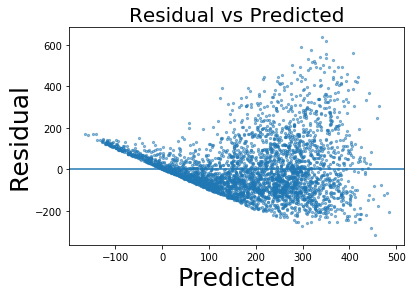

In [86]:
## Run a linear regression model

from sklearn import linear_model

lm = linear_model.LinearRegression()
lm.fit(X_train, y_train)

predicted = lm.predict(X_test)
residual = y_test - predicted

plt.scatter(predicted, residual,s=5,alpha=.5)
plt.xlabel('Predicted',fontsize=25)
plt.ylabel('Residual',fontsize=25)
plt.axhline(y=0)
plt.title('Residual vs Predicted',fontsize=20)

In [87]:
## Compute error metric and evaluate accuracy

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

rmse = np.sqrt(mean_squared_error(y_test, predicted))

print(rmse)
print(r2_score(y_test, predicted))

132.43406147260654
0.4742873921326981


From the pattern in the residual vs. predicted graph alone we can tell that some factor is impacting the model. We are off by a margin of about 132 bike rentals on average. There could be a non-linear trend in the data that we are missing. 

A decision tree can help root out non-linear trends and likely yield a higher accuracy.

### Decision Tree

Text(0.5, 1.0, 'Residual vs Predicted')

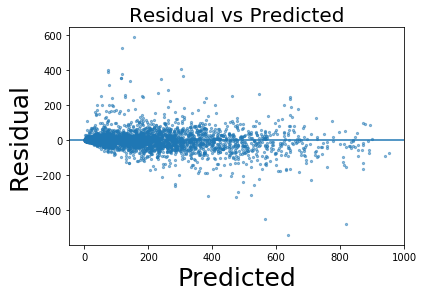

In [69]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor(max_features='auto')
dtr.fit(X_train, y_train)

predicted = dtr.predict(X_test)
residual = y_test - predicted

plt.scatter(predicted, residual,s=5,alpha=.5)
plt.xlabel('Predicted',fontsize=25)
plt.ylabel('Residual',fontsize=25)
plt.axhline(y=0)
plt.title('Residual vs Predicted',fontsize=20)

In [70]:
rmse = np.sqrt(mean_squared_error(y_test, predicted))

print(rmse)
print(r2_score(y_test, predicted))

57.67567599812937
0.9002909948283501


By taking the nonlinear predictors into account, the decision tree indeed yields a higher accuracy. Our RMSE more than halved. 

Decision trees by themselves _can_ result in a model that overfits however. We can remedy this by using a random forest which aggregates many trees and weeds out the overfitting tendency. 

### Random Forests

Text(0.5, 1.0, 'Residual vs Predicted')

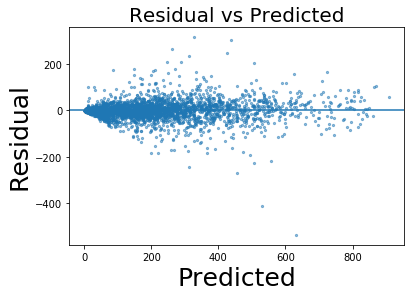

In [76]:
from sklearn.ensemble import RandomForestRegressor

clf = RandomForestRegressor(n_estimators=50, random_state=1, min_samples_leaf=2)
clf.fit(X_train, y_train)

predicted = clf.predict(X_test)
residual = y_test - predicted

plt.scatter(predicted, residual,s=5,alpha=.5)
plt.xlabel('Predicted',fontsize=25)
plt.ylabel('Residual',fontsize=25)
plt.axhline(y=0)
plt.title('Residual vs Predicted',fontsize=20)

In [77]:
rmse = np.sqrt(mean_squared_error(y_test, predicted))

print(rmse)
print(r2_score(y_test, predicted))

40.18322003597106
0.9516007683379993


Using a forest of 50 trees indeed lowered our error and improved overall model accuracy.